In [21]:
%load_ext autoreload
%autoreload 2
from pcntoolkit.dataio.norm_data import NormData
from pcntoolkit.normative_model import NormativeModel
import pandas as pd
import importlib
import pcntoolkit
importlib.reload(pcntoolkit)
from pcntoolkit.math_functions.thrive import get_correlation_matrix
import matplotlib.pyplot as plt
import copy

model = NormativeModel.load("save_dir_SC_all_regions")
#model = model[:, 'Left-Lateral-Ventricle']
test = pd.read_pickle("/Users/johannabayer/Documents/DATA/SC/test_SC_demented_adults_ADNI.pkl")


covariates = ["age"]
batch_effects = ["sex", "site_id2"]

# features_to_model = [
#     'L_bankssts',
# ]


features_to_model = [
    'Left-Lateral-Ventricle',
]

# features_to_model = [
#  'L_bankssts',
#  'L_caudalanteriorcingulate',
#  'L_caudalmiddlefrontal',
#  'L_cuneus',
#  'L_entorhinal',
#  'L_fusiform',
#  'L_inferiorparietal',
#  'L_inferiortemporal',
#  'L_isthmuscingulate',
#  'L_lateraloccipital',
#  'L_lateralorbitofrontal',
#  'L_lingual',
#  'L_medialorbitofrontal',
#  'L_middletemporal',
#  'L_parahippocampal',
#  'L_paracentral',
#  'L_parsopercularis',
#  'L_parsorbitalis',
#  'L_parstriangularis',
#  'L_pericalcarine',
#  'L_postcentral',
#  'L_posteriorcingulate',
#  'L_precentral',
#  'L_precuneus',
#  'L_rostralanteriorcingulate',
#  'L_rostralmiddlefrontal',
#  'L_superiorfrontal',
#  'L_superiorparietal',
#  'L_superiortemporal',
#  'L_supramarginal',
#  'L_frontalpole',
#  'L_temporalpole',
#  'L_transversetemporal',
#  'L_insula',
#  'R_bankssts',
#  'R_caudalanteriorcingulate',
#  'R_caudalmiddlefrontal',
#  'R_cuneus',
#  'R_entorhinal',
#  'R_fusiform',
#  'R_inferiorparietal',
#  'R_inferiortemporal',
#  'R_isthmuscingulate',
#  'R_lateraloccipital',
#  'R_lateralorbitofrontal',
#  'R_lingual',
#  'R_medialorbitofrontal',
#  'R_middletemporal',
#  'R_parahippocampal',
#  'R_paracentral',
#  'R_parsopercularis',
#  'R_parsorbitalis',
#  'R_parstriangularis',
#  'R_pericalcarine',
#  'R_postcentral',
#  'R_posteriorcingulate',
#  'R_precentral',
#  'R_precuneus',
#  'R_rostralanteriorcingulate',
#  'R_rostralmiddlefrontal',
#  'R_superiorfrontal',
#  'R_superiorparietal',
#  'R_superiortemporal',
#  'R_supramarginal',
#  'R_frontalpole',
#  'R_temporalpole',
#  'R_transversetemporal',
#  'R_insula'
# ]

norm_test = NormData.from_dataframe(
    name="test", dataframe=test, covariates=covariates, batch_effects=batch_effects, response_vars=features_to_model
)

norm_test = norm_test.sel(response_vars=features_to_model)

path = "/Users/johannabayer/Documents/Github/PCNtoolkit_Velocity/pcntoolkit/save_dir_SC_all_regions/results/Velocity"
# get correlation matrix
#get_correlation_matrix(norm_test, bandwidth=3, covariate_name="age", matrix_path=path )

model.compute_correlation_matrix(norm_test, bandwidth=5, covariate="age", matrix_path=path)


import numpy as np
import pandas as pd
import xarray as xr
from pcntoolkit import NormData

# Extract structure from existing NormData
response_vars = norm_test.response_vars.to_numpy()
batch_effect_names = norm_test.batch_effects.coords["batch_effect_dims"].to_numpy().tolist()
n_rv = len(response_vars)

# Define grid axes
ages = np.arange(0, 100, 1)
z_scores = np.arange(-3.0, 4.0, 1)

# All age × Z combinations
age_grid, z_grid = np.meshgrid(ages, z_scores)
age_flat = age_grid.flatten()
z_flat = z_grid.flatten()
n = len(age_flat)

# Build dataframe
df_dict = {
    "age": age_flat,
    "subjects": np.arange(n),
}

# Add one reference value per batch effect from first observation
#ref_batch_values = norm_test.batch_effects.isel(observations=500).to_numpy()


#for be_name, be_val in zip(batch_effect_names, ref_batch_values):
#    df_dict[be_name] = np.full(n, be_val)

# Add dummy response columns
for rv in response_vars:
    df_dict[rv] = np.zeros(n)

df_grid = pd.DataFrame(df_dict)

grid_data = NormData.from_dataframe(
    name="grid",
    dataframe=df_grid,
    covariates=["age"],
    #batch_effects=batch_effect_names,
    response_vars=response_vars.tolist(),
    subject_ids="subjects",
)

# Same Z for all response vars at each row
Z = np.tile(z_flat[:, None], (1, n_rv))

grid_data["Z"] = xr.DataArray(
    Z,
    dims=("observations", "response_vars"),
    coords={
        "observations": grid_data.coords["observations"],
        "response_vars": response_vars,
    },
)


#ref_batch_values = norm_test.batch_effects.isel(observations=500).to_numpy()
print(z_scores)
df_grid


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Process: 12339 - 2026-05-04 17:58:10 - Dataset "test" created.
    - 50468 observations
    - 50468 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (2)
	site_id2 (125)
    
Process: 12339 - 2026-05-04 17:58:10 - Dataset "grid" created.
    - 700 observations
    - 700 unique subjects
    - 1 covariates
    - 1 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
[-3. -2. -1.  0.  1.  2.  3.]


,age,subjects,Left-Lateral-Ventricle
0,0,0,0.0
1,1,1,0.0
2,2,2,0.0
3,3,3,0.0
4,4,4,0.0
...,...,...,...
695,95,695,0.0
696,96,696,0.0
697,97,697,0.0
698,98,698,0.0


In [22]:
mask_sex = norm_test.batch_effects.sel(batch_effect_dims="sex").isin(["0.0"])
mask_site = norm_test.batch_effects.sel(batch_effect_dims="site_id2").isin(["2.0", "3.0"])

norm_test_subset = norm_test.sel(observations=norm_test.observations[mask_sex.values & mask_site.values])
norm_test_subset.batch_effects

<xarray.DataArray 'batch_effects' (observations: 73, batch_effect_dims: 2)> Size: 19kB
array([['0.0', '2.0'],
       ['0.0', '2.0'],
       ['0.0', '2.0'],
       ['0.0', '2.0'],
       ['0.0', '2.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
...
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0'],
       ['0.0', '3.0']], dtype='<U32')
Coordinates:
  * observations       (observations) int64 584B 17 18 19 20 ... 2907 2917 2919
  * batch_effect_dims  (batch_effect_dims) <U8 64B 'sex' 'site_id2'

In [23]:
def subset_model(model, response_vars):
    sub = copy.deepcopy(model)
    sub.response_vars = [rv for rv in response_vars if rv in model.response_vars]
    sub.regression_models = {rv: sub.regression_models[rv] for rv in sub.response_vars}
    sub.outscalers = {rv: sub.outscalers[rv] for rv in sub.response_vars}
    return sub

small_model = subset_model(model, features_to_model)
small_model.unique_batch_effects["site_id2"] = ["2.0", "3.0"]
small_model.unique_batch_effects["sex"] = ["0.0"]

In [24]:
small_model.compute_thrivelines(norm_test_subset, span=5, covariate="age", z_thrive=1.96, grid_data=grid_data, matrix_path=path)

Sampling: []
Sampling: []
Sampling: []
Sampling: []


<xarray.NormData> Size: 72kB
Dimensions:            (observations: 73, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, offset: 2, dummy_obs: 700,
                        be_combo: 2)
Coordinates:
  * observations       (observations) int64 584B 17 18 19 20 ... 2907 2917 2919
  * response_vars      (response_vars) <U22 88B 'Left-Lateral-Ventricle'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U8 64B 'sex' 'site_id2'
  * offset             (offset) int64 16B 0 5
  * dummy_obs          (dummy_obs) int64 6kB 0 1 2 3 4 5 ... 695 696 697 698 699
  * be_combo           (be_combo) int64 16B 0 1
    sex                (be_combo) <U3 24B '0.0' '0.0'
    site_id2           (be_combo) <U3 24B '2.0' '3.0'
Data variables:
    subject_ids        (observations) int64 584B 17 18 19 20 ... 2907 2917 2919
    Y                  (observations, response_vars) float64 584B -0.5285 ......
    X                  (observations, covariates) float64 584B -2.0 ... -0.4455
    batch_effects      (observations, batch_effect_dims) <U32 19kB '0.0' ... ...
    thrive_Z           (dummy_obs, response_vars, offset) float64 11kB -3.0 ....
    thrive_Y           (dummy_obs, response_vars, offset, be_combo) float64 22kB ...
    thrive_X           (dummy_obs, offset) float64 11kB -2.193 -1.975 ... 2.351
Attributes:
    real_ids:                       False
    is_scaled:                      True
    name:                           test
    unique_batch_effects:           {np.str_('sex'): [np.str_('0.0'), np.str_...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(37.3...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('0.0'): {np.str...
    thrive_covariate:               age
    z_thrive:                       1.96

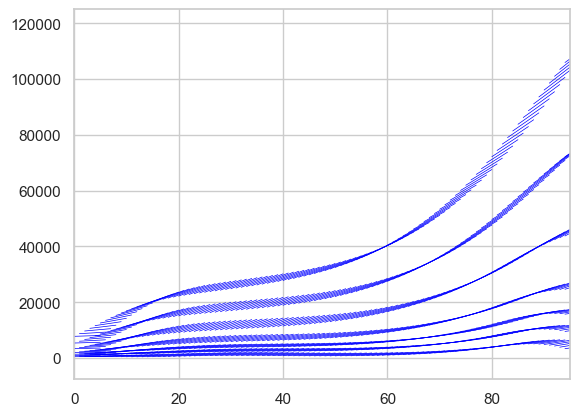

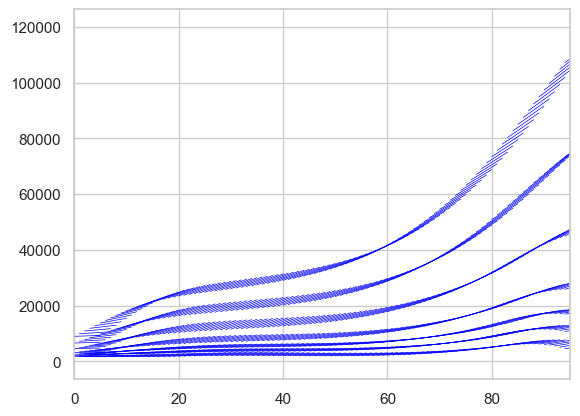

<xarray.DataArray 'thrive_X' (dummy_obs: 700, offset: 2)> Size: 11kB
array([[-2.19337885, -1.97489658],
       [-2.1496824 , -1.93120013],
       [-2.10598594, -1.88750368],
       ...,
       [ 2.04517706,  2.26365933],
       [ 2.08887352,  2.30735578],
       [ 2.13256997,  2.35105223]], shape=(700, 2))
Coordinates:
  * dummy_obs  (dummy_obs) int64 6kB 0 1 2 3 4 5 6 ... 694 695 696 697 698 699
  * offset     (offset) int64 16B 0 5

In [25]:
from pcntoolkit.util.plotter import plot_centiles, plot_centiles_advanced
import matplotlib.pyplot as plt
thrive_Z = norm_test_subset["thrive_Z"]
thrive_X = norm_test_subset["thrive_X"]


import matplotlib.pyplot as plt
import numpy as np

thrive_Z = norm_test_subset["thrive_Z"]
thrive_X = norm_test_subset["thrive_X"]
#thrive_Y = norm_test_subset["thrive_Y"]

thrive_Y= norm_test_subset.thrive_Y.set_index(be_combo=["sex", "site_id2"]).sel(sex="0.0", site_id2="2.0")


thrive_X_raw = model.inscalers["age"].inverse_transform(thrive_X)
thrive_Y_raw = model.outscalers[features_to_model[0]].inverse_transform(thrive_Y)   


for x, z in zip(thrive_X_raw, thrive_Y_raw):
    plt.plot(np.ravel(x), np.ravel(z), color = "blue", linewidth=0.5)

plt.xlim(0, 95) 
plt.show()


thrive_Y= norm_test_subset.thrive_Y.set_index(be_combo=["sex", "site_id2"]).sel(sex="0.0", site_id2="3.0")
thrive_X_raw = model.inscalers["age"].inverse_transform(thrive_X)
thrive_Y_raw = model.outscalers[features_to_model[0]].inverse_transform(thrive_Y)   


for x, z in zip(thrive_X_raw, thrive_Y_raw):
    plt.plot(np.ravel(x), np.ravel(z), color = "blue", linewidth=0.5)

plt.xlim(0, 95) 
plt.show()
thrive_X

In [14]:
norm_test_subset 

<xarray.NormData> Size: 72kB
Dimensions:            (observations: 73, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, offset: 2, dummy_obs: 700,
                        be_combo: 2)
Coordinates:
  * observations       (observations) int64 584B 17 18 19 20 ... 2907 2917 2919
  * response_vars      (response_vars) <U22 88B 'Left-Lateral-Ventricle'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U8 64B 'sex' 'site_id2'
  * offset             (offset) int64 16B 0 3
  * dummy_obs          (dummy_obs) int64 6kB 0 1 2 3 4 5 ... 695 696 697 698 699
  * be_combo           (be_combo) int64 16B 0 1
    sex                (be_combo) <U3 24B '0.0' '0.0'
    site_id2           (be_combo) <U3 24B '2.0' '3.0'
Data variables:
    subject_ids        (observations) int64 584B 17 18 19 20 ... 2907 2917 2919
    Y                  (observations, response_vars) float64 584B -0.5285 ......
    X                  (observations, covariates) float64 584B -2.0 ... -0.4455
    batch_effects      (observations, batch_effect_dims) <U32 19kB '0.0' ... ...
    thrive_Z           (dummy_obs, response_vars, offset) float64 11kB -3.0 ....
    thrive_Y           (dummy_obs, response_vars, offset, be_combo) float64 22kB ...
    thrive_X           (dummy_obs, offset) float64 11kB -2.193 -2.062 ... 2.264
Attributes:
    real_ids:                       False
    is_scaled:                      True
    name:                           test
    unique_batch_effects:           {np.str_('sex'): [np.str_('0.0'), np.str_...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(37.3...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('0.0'): {np.str...
    thrive_covariate:               age
    z_thrive:                       1.96

In [15]:
# thriveline_data already has thrive_Z and thrive_X computed
plot_centiles_advanced(
    model=small_model,
    scatter_data=norm_test_subset,
    show_thrivelines=True,
    thriveline_data=norm_test_subset,   # or whatever NormData has thrive_Z/thrive_X
    batch_effects={"sex": ["0.0"], "site_id2": ["2.0"]},
)


Process: 12339 - 2026-04-29 20:49:33 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 12339 - 2026-04-29 20:49:33 - Computing centiles for 1 response variables.
Process: 12339 - 2026-04-29 20:49:33 - Computing centiles for Left-Lateral-Ventricle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


Process: 12339 - 2026-04-29 20:49:50 - Harmonizing data on 1 response variables.
Process: 12339 - 2026-04-29 20:49:50 - Harmonizing data for Left-Lateral-Ventricle.


Sampling: []


ValueError: new dimensions ('observations',) must be a superset of existing dimensions ('dummy_obs',)

In [4]:
import copy

def subset_model(model, response_vars):
    sub = copy.deepcopy(model)
    sub.response_vars = [rv for rv in response_vars if rv in model.response_vars]
    sub.regression_models = {rv: sub.regression_models[rv] for rv in sub.response_vars}
    sub.outscalers = {rv: sub.outscalers[rv] for rv in sub.response_vars}
    return sub

small_model = subset_model(model, features_to_model)
small_model

In [7]:
import matplotlib.pyplot as plt
thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]


import matplotlib.pyplot as plt
import numpy as np

thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]
thrive_Y = norm_test["thrive_Y"]

thrive_X_raw = small_model.inscalers["age"].inverse_transform(thrive_X)
thrive_Y_raw = small_model.outscalers[features_to_model[0]].inverse_transform(thrive_Y)   



plot_centiles_advanced(
    model=small_model,
    response_vars=[features_to_model[0]],     # filtered to known sites
    harmonize_data=False,
    centiles=[0.01, 0.05, 0.32, 0.5, 0.68, 0.95, 0.99],
)

for x, z in zip(thrive_X, thrive_Y):
    plt.plot(np.ravel(x), np.ravel(z), color = "blue", linewidth=0.5)

plt.xlim(0, 100) 
plt.show()
thrive_Y_raw



KeyError: "No variable named 'thrive_Z'. Variables on the dataset include ['subject_ids', 'Y', 'X', 'batch_effects', 'observations', 'response_vars', 'covariates', 'batch_effect_dims']"

In [7]:
print("cormat size:", small_model.correlation_matrix.shape)
print("covariate_ranges:", small_model.covariate_ranges["age"])


cormat size: (1, 99, 99)
covariate_ranges: {'min': 2.091666666666667, 'max': 100.0}


Process: 12339 - 2026-04-29 20:35:32 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	site_id2 (1)
	sex (1)
    
Process: 12339 - 2026-04-29 20:35:32 - Computing centiles for 1 response variables.
Process: 12339 - 2026-04-29 20:35:32 - Computing centiles for Left-Lateral-Ventricle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


AttributeError: 'NormData' object has no attribute 'thrive_X'

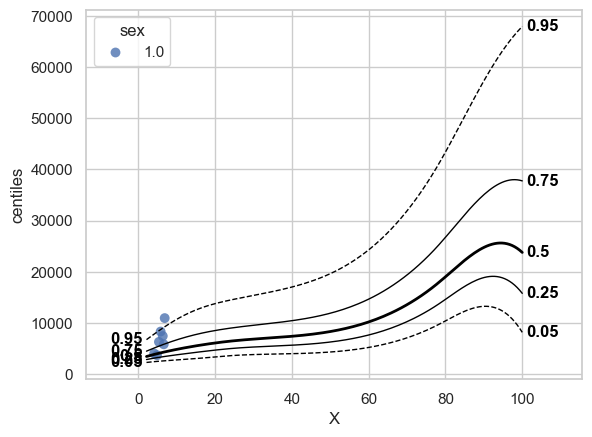

In [8]:
known_sites = list(small_model.unique_batch_effects["site_id2"])
mask = norm_test.batch_effects.sel(batch_effect_dims="site_id2").isin(known_sites)
norm_test_known = norm_test.sel(observations=norm_test.observations[mask.values])

from matplotlib.pyplot import grid

from pcntoolkit.util.plotter import plot_centiles_advanced

# Provide all batch-effect dimensions expected by the model.
# Using only site_id2 causes a shape mismatch when computing centiles.
plot_centiles_advanced(
    model=small_model,
    response_vars=["Left-Lateral-Ventricle"],
    scatter_data=norm_test_known,
    grid_data=grid_data,
    batch_effects={"site_id2": ["2.0"], "sex": ["1.0"]},
    show_thrivelines=True,
    harmonize_data=False,
    z_thrive=1.96,
)


Sampling: []


Process: 90317 - 2026-04-17 10:40:20 - Dataset "grid" created.
    - 1050 observations
    - 1050 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	site_id2 (1)
	sex (1)
    
Process: 90317 - 2026-04-17 10:40:20 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 90317 - 2026-04-17 10:40:20 - Computing centiles for 1 response variables.
Process: 90317 - 2026-04-17 10:40:20 - Computing centiles for L_bankssts.


Sampling: []
Sampling: []
Sampling: []
Sampling: []


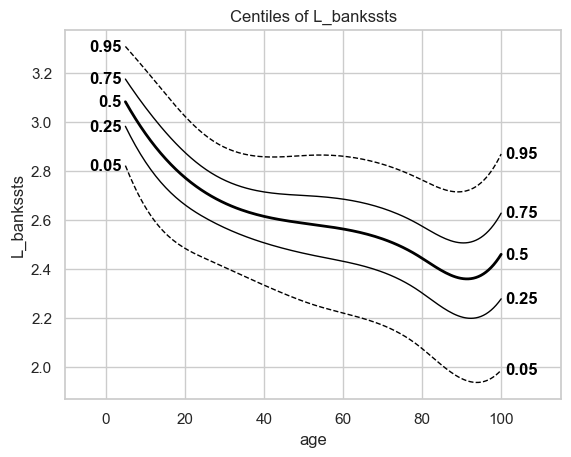

In [7]:
# Prepare grid_data: ages across lifespan, Z set to your anchor values
import xarray as xr
import numpy as np
from pcntoolkit.util.plotter import plot_centiles_advanced

ages = np.linspace(model.covariate_ranges["age"]["min"], 
                   model.covariate_ranges["age"]["max"] - model.correlation_matrix.shape[1]//10, 
                   150)

# Create one row per anchor Z per age — here 9 Z anchors × 150 ages
z_anchors = [-3, -3, -1, 0, 1, 2, 3]
rows = []
for z in z_anchors:
    for age in ages:
        rows.append({"age": age, "site_id2": "2.0", "sex": "1.0","Left-Lateral-Ventricle": 0})
grid_df = pd.DataFrame(rows)
grid_data = NormData.from_dataframe("grid", grid_df, covariates=["age"], 
                                     response_vars=["Left-Lateral-Ventricle"],
                                     batch_effects=["site_id2", "sex"])
# Set Z scores to anchor values
grid_data["Z_thrive"] = xr.DataArray(
    np.repeat(z_anchors, len(ages)).reshape(-1, 1),
    dims=("observations", "response_vars"),
    coords={"observations": grid_data.observations, "response_vars": ["Left-Lateral-Ventricle"]}
)

plot_centiles_advanced(
    model=small_model,
    response_vars=["Left-Lateral-Ventricle"],
    grid_data=grid_data,
    #batch_effects={"site_id2": ["1.0"], "sex": ["1.0"]},
    harmonize_data=True,
)



In [11]:
model.outscalers

{'L_inferiortemporal': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163bde810>,
 'L_temporalpole': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163c44200>,
 'L_postcentral': <pcntoolkit.math_functions.scaler.StandardScaler at 0x164c11550>,
 'R_isthmuscingulate': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163bdd280>,
 'L_superiortemporal': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163c20080>,
 'R_parsopercularis': <pcntoolkit.math_functions.scaler.StandardScaler at 0x1632fed20>,
 'R_cuneus': <pcntoolkit.math_functions.scaler.StandardScaler at 0x1632fe990>,
 'R_caudalanteriorcingulate': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163bdf440>,
 'L_precentral': <pcntoolkit.math_functions.scaler.StandardScaler at 0x163bcc350>,
 'L_inferiorparietal': <pcntoolkit.math_functions.scaler.StandardScaler at 0x16542dfa0>,
 'R_parstriangularis': <pcntoolkit.math_functions.scaler.StandardScaler at 0x16579ec30>,
 'L_posteriorcingulate': <pcntoolkit.mat

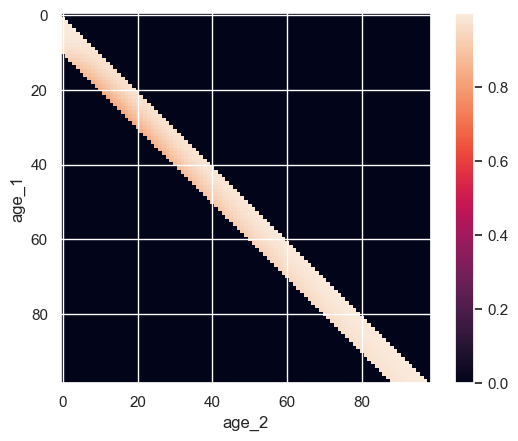

In [16]:
cormat = model.correlation_matrix

import matplotlib.pyplot as plt
plt.imshow(cormat.sel(response_vars="Left-Lateral-Ventricle").values)
plt.colorbar()
plt.xlabel("age_2")
plt.ylabel("age_1")
plt.show()


In [ ]:
known_sites = list(small_model.unique_batch_effects["site_id2"])
mask = norm_test.batch_effects.sel(batch_effect_dims="site_id2").isin(known_sites)
norm_test_known = norm_test.sel(observations=norm_test.observations[mask.values])
from pcntoolkit.util.plotter import plot_centiles
plot_centiles(small_model, 
              scatter_data=norm_test_known)

Sampling: []


Process: 32837 - 2026-04-16 11:16:54 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 32837 - 2026-04-16 11:16:54 - Computing centiles for 1 response variables.
Process: 32837 - 2026-04-16 11:16:54 - Computing centiles for Left-Lateral-Ventricle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


Process: 32837 - 2026-04-16 11:17:05 - Harmonizing data on 1 response variables.
Process: 32837 - 2026-04-16 11:17:05 - Harmonizing data for Left-Lateral-Ventricle.


In [6]:
def make_grid_data(
        self,
        covariate: str | None = None,
        covariate_range: tuple[float, float] | None = None,
        batch_effects: dict | None = None,
        n_points: int = 150,
    ) -> "NormData":
        """Create the synthetic grid dataset used for centile and thriveline plotting.

        Parameters
        ----------
        covariate : str, optional
            The covariate to use as the x-axis. Defaults to the first covariate.
        covariate_range : tuple[float, float], optional
            (min, max) range for the covariate. Defaults to the observed range.
        batch_effects : dict, optional
            Batch effects to assign. Keys are batch effect names, values are the
            chosen level. Defaults to the most frequent level per batch effect.
        n_points : int, optional
            Number of evenly-spaced grid points. Defaults to 150.

        Returns
        -------
        NormData
            Grid dataset identical to the one used internally by plot_centiles_advanced.
        """
        import pandas as pd
        from pcntoolkit.dataio.norm_data import NormData

        if covariate is None:
            covariate = self.covariates[0]

        cov_min = (covariate_range[0] if covariate_range else None) or self.covariate_ranges[covariate]["min"]
        cov_max = (covariate_range[1] if covariate_range else None) or self.covariate_ranges[covariate]["max"]

        if batch_effects is None:
            batch_effects = {k: [max(v.items(), key=lambda x: x[1])[0]] for k, v in self.batch_effect_counts.items()}

        grid_covariates = np.linspace(cov_min, cov_max, n_points)
        df = pd.DataFrame({covariate: grid_covariates})

        for cov in self.covariates:
            if cov != covariate:
                minc = self.covariate_ranges[cov]["min"]
                maxc = self.covariate_ranges[cov]["max"]
                df[cov] = (minc + maxc) / 2

        for be, v in batch_effects.items():
            df[be] = v[0] if isinstance(v, list) else v

        for rv in [str(rv) for rv in self.response_vars]:
            df[rv] = 0

        return NormData.from_dataframe(
            "centile",
            dataframe=df,
            covariates=self.covariates,
            response_vars=self.response_vars,
            batch_effects=list(batch_effects.keys()),
        )
        
grid_data2 = model.make_grid_data()
grid_data2

Process: 64469 - 2026-04-16 12:58:58 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 51 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    


<xarray.NormData> Size: 76kB
Dimensions:            (observations: 150, response_vars: 51, covariates: 1,
                        batch_effect_dims: 2)
Coordinates:
  * observations       (observations) int64 1kB 0 1 2 3 4 ... 146 147 148 149
  * response_vars      (response_vars) <U29 6kB 'Right-Pallidum' ... 'Left-Am...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U8 64B 'sex' 'site_id2'
Data variables:
    subject_ids        (observations) int64 1kB 0 1 2 3 4 ... 146 147 148 149
    Y                  (observations, response_vars) int64 61kB 0 0 0 ... 0 0 0
    X                  (observations, covariates) float64 1kB 2.092 ... 100.0
    batch_effects      (observations, batch_effect_dims) <U4 5kB '0.0' ... '5...
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           centile
    unique_batch_effects:           {np.str_('sex'): [np.str_('0.0')], np.str...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(51.0...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('0.0'): {np.str...

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
<xarray.DataArray (dummy_obs: 700, offset: 2)> Size: 11kB
array([[-3.        , -2.96354221],
       [-3.        , -2.90007745],
       [-3.        , -2.82653185],
       ...,
       [ 3.        ,  3.14366002],
       [ 3.        ,  1.96      ],
       [ 3.        ,  1.96      ]], shape=(700, 2))
Coordinates:
  * offset   (offset) int64 16B 0 3
Dimensions without coordinates: dummy_obs
<xarray.DataArray (dummy_obs: 700, offset: 2)> Size: 11kB
array([[  0.,   3.],
       [  1.,   4.],
       [  2.,   5.],
       ...,
       [ 97., 100.],
       [ 98., 101.],
       [ 99., 102.]], shape=(700, 2))
Coordinates:
  * offset   (offset) int64 16B 0 3
Dimensions without coordinates: dummy_obs


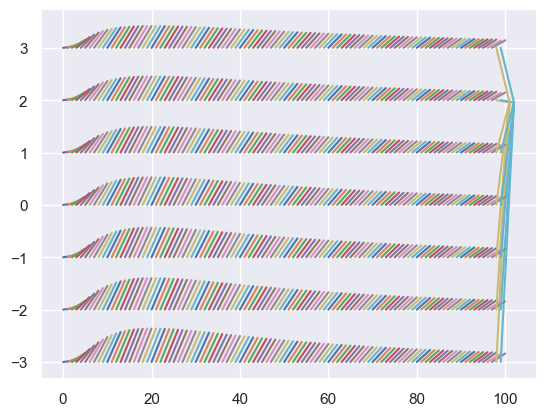

In [10]:
%load_ext autoreload
%autoreload 2
from pcntoolkit.math_functions.thrive import get_thrive_Z_X
import numpy as np
import xarray as xr

# Grab the correlation matrix for one response var
cormat = model.correlation_matrix.sel(response_vars=features_to_model[0])

# Take a few rows from grid_data
X = grid_data.X
Z = grid_data.Z.sel(response_vars=features_to_model[0])

# Inverse-scale X to get raw ages
X_cov = model.inscalers["age"].inverse_transform(X.sel(covariates="age", drop=False))

# Call the function directly
thrive_Z, thrive_X = get_thrive_Z_X(cormat, X_cov, Z, span=3, z_thrive=1.96)

print(thrive_Z)
print(thrive_X)

plt.plot(thrive_X.values.T, thrive_Z.values.T)
plt.show()


Sampling: []


{'sex': ['0.0', '1.0'], 'site_id2': ['1.0', '10.0', '100.0', '101.0', '102.0', '103.0', '104.0', '105.0', '106.0', '107.0', '108.0', '109.0', '11.0', '110.0', '111.0', '112.0', '113.0', '114.0', '115.0', '116.0', '117.0', '118.0', '119.0', '12.0', '120.0', '121.0', '122.0', '123.0', '124.0', '13.0', '14.0', '15.0', '16.0', '17.0', '18.0', '19.0', '2.0', '20.0', '21.0', '22.0', '23.0', '24.0', '25.0', '26.0', '27.0', '28.0', '29.0', '3.0', '30.0', '31.0', '32.0', '33.0', '34.0', '35.0', '36.0', '37.0', '38.0', '39.0', '4.0', '40.0', '41.0', '42.0', '43.0', '44.0', '45.0', '46.0', '47.0', '48.0', '49.0', '5.0', '50.0', '51.0', '52.0', '53.0', '54.0', '55.0', '56.0', '57.0', '58.0', '59.0', '6.0', '60.0', '61.0', '62.0', '63.0', '64.0', '65.0', '66.0', '67.0', '68.0', '69.0', '7.0', '70.0', '71.0', '72.0', '73.0', '74.0', '75.0', '76.0', '77.0', '78.0', '79.0', '8.0', '80.0', '81.0', '82.0', '83.0', '84.0', '85.0', '86.0', '87.0', '88.0', '89.0', '9.0', '90.0', '91.0', '92.0', '93.0', '94

Sampling: []


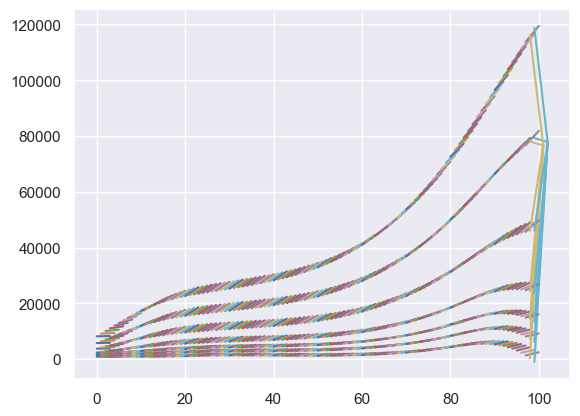

In [14]:
responsevar = features_to_model[0]
n_obs = X.shape[0]
dummy_obs_coord = grid_data.coords["observations"].values
span = 3
offsets = np.array([0, span])

# Pick a batch effect combination
print(model.unique_batch_effects)  # check available keys/values first
be_combo = {"sex": "0.0", "site_id2": "20.0"}  # replace with actual values

be_keys = sorted(model.unique_batch_effects.keys())

# Build a batch effect DataArray — same combo repeated for every observation
raw_be = xr.DataArray(
    np.tile([str(be_combo[k]) for k in be_keys], (n_obs, 1)),
    dims=("observations", "batch_effect_dims"),
    coords={"observations": dummy_obs_coord, "batch_effect_dims": be_keys},
)
be_encoded = model.map_batch_effects(raw_be)

# Backward transform thrive_Z → thrive_Y for each offset
thrive_Y_list = []
for io, o in enumerate(offsets):
    this_Z = thrive_Z.isel(offset=io)
    y = model[responsevar].backward(X, be_encoded, this_Z)
    thrive_Y_list.append(y.values.ravel())

thrive_Y = xr.DataArray(
    np.stack(thrive_Y_list, axis=1),
    dims=("dummy_obs", "offset"),
    coords={"offset": offsets, "dummy_obs": dummy_obs_coord},
)

thrive_Y_unscaled = xr.DataArray(
    model.outscalers[responsevar].inverse_transform(thrive_Y.values),
    dims=thrive_Y.dims,
    coords=thrive_Y.coords,
)

plt.plot(thrive_X.values.T, thrive_Y_unscaled.values.T)
plt.show()


#plt.plot(thrive_X.values.T, thrive_Y.values.T)
#plt.show()


Process: 44179 - 2026-04-23 18:22:38 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	site_id2 (1)
	sex (1)
    
Process: 44179 - 2026-04-23 18:22:38 - Computing centiles for 1 response variables.
Process: 44179 - 2026-04-23 18:22:38 - Computing centiles for Left-Lateral-Ventricle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


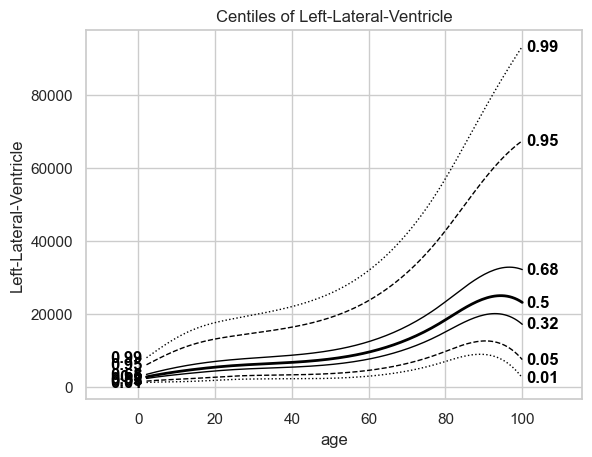

In [17]:
plot_centiles_advanced(
    model=small_model,
    response_vars=[features_to_model[0]],     # filtered to known sites
    harmonize_data=False,
    batch_effects={"site_id2": ["20.0"], "sex": ["0.0"]},
    centiles=[0.01, 0.05, 0.32, 0.5, 0.68, 0.95, 0.99],
)


In [ ]:
# thriveline_data already has thrive_Z and thrive_X computed
plot_centiles_advanced(
    model,
    scatter_data=norm_test,
    show_thrivelines=True,
    thriveline_data=centile_data,   # or whatever NormData has thrive_Z/thrive_X
    batch_effects={"sex": ["0.0"], "site_id2": ["2.0"]},
)
